# Импорты библиотек

In [34]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Загрузка видео 

In [35]:
cap = cv2.VideoCapture('mouse_1.avi')

Считываем первый кадр

In [36]:
if not cap.isOpened():
    print("Ошибка: не удалось открыть видео")
    exit()
success, img3 = cap.read()
img3 = cv2.cvtColor(img3, cv2.COLOR_BGR2RGB)


Визуализация первого кадра

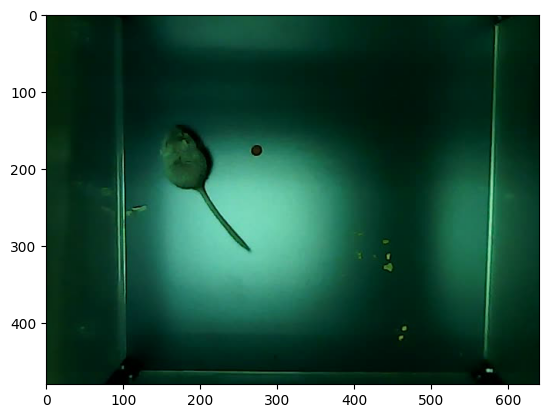

In [37]:
plt.imshow(img3)

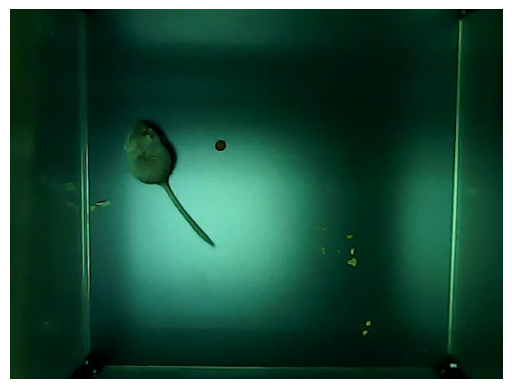

In [45]:
# Отображаем изображение
plt.imshow(img3)
plt.axis('off')  # Отключаем оси (по желанию)
# Сохраняем
plt.savefig('mice.png', dpi=300, bbox_inches='tight')
plt.show()

# Преобразование видеофайла в последовательность изображений 

In [38]:
# Инициализируем счетчик кадров, начинаем с 1
i=1

# Создаем пустой список для хранения всех кадров
imgs = []
 # Выводит 1 (начальное значение счетчика)
# Цикл выполняется, пока успешно читаются кадры

while True:
    # Читаем следующий кадр
    success, img = cap.read()
    
    # Проверяем УСПЕШНОСТЬ ЧТЕНИЯ И непустоту кадра
    if not success or img is None or img.size == 0:
        print(f"Конец видео или ошибка чтения на кадре {i}")
        break
    
    # Конвертируем в серый только ВАЛИДНЫЙ кадр
    img_grey = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    imgs.append(img_grey)
    
    i += 1

# Освобождаем ресурсы
cap.release()
print(f"Загружено {len(imgs)} кадров")

Конец видео или ошибка чтения на кадре 6076
Загружено 6075 кадров


Обращаемся 1000 элементу массива и выведем 

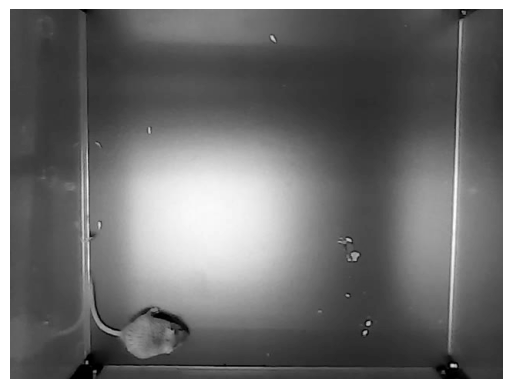

In [39]:

plt.imshow(imgs[4000], cmap='gray')

plt.axis('off')  # Отключаем оси (по желанию)
# Сохраняем
plt.savefig('mice_gray.png', dpi=300, bbox_inches='tight')
plt.show()


# Модель усредненного фона

In [40]:
def sr_mod_fon (arr_image):
# Создаем массив mod_fon (модель фона), заполненный нулями, размером как у второго изображения в списке (индекс 1)
  mod_fon = np.zeros(arr_image[1].shape, dtype='uint8')
#Создает двумерный массив sum размером кадра 480×640 пикселей, заполненный нулями. 
#Здесь будут накапливаться суммы значений пикселей.
  sum=np.zeros([480,640])
#Цикл по всем изображениям, кроме последних 10
  for k in range(len(arr_image)-10):
#Берем k-ое изображение из массива arr_image и присваивает переменной image.
    image=arr_image[k]
    #Внешний цикл по строкам изображения
    for i in range(len(image)):
    #Внутренний цикл по столбцам изображения
      for j in range(len(image[i])):
        #К текущей сумме пикселя с координатами (i,j) добавляет значение пикселя из текущего изображения. Накопление суммы по всем кадрам
        sum[i,j]=sum[i,j]+image[i,j]
#Делит накопленную сумму на количество кадров k. Получается среднее арифметическое значений каждого пикселя по всем кадрам.
  sum=sum/k
  return sum


Данная функция складывает значения пикселей, которые занимают одно и тоже пространственное расположение. 
А после прохода по всему массиву береться среднее от количества изображений.

In [41]:
amt=sr_mod_fon(imgs)

Поскольку на выходе мы получаем не целые значения пикселей, то их нужно округлить. 
Для это воспользуемся функцией библиотеки np для перевода в требуемый формат изображения, а именно np.uint8

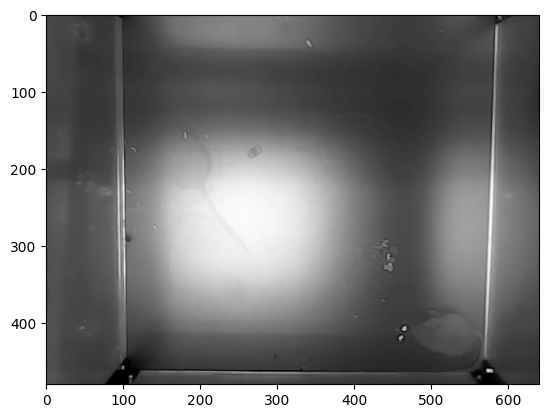

In [42]:
new=np.uint8(amt)
plt.imshow(new, cmap='gray')

ПО итогу, нам удалось получить карту фона, полученную усреднением. Мы видим, что на карте видно кортур мышки в 2-х местах. Это происходит потому, что мышка в этих местазх достаточно долго сидит и не двигается. Это затрудняет определение. ПОэтому вычитание пикселей между картой фона и изображением (для примера возьмем 2000-чное) мы будем использовать пороговую бинаризацию по разнице.

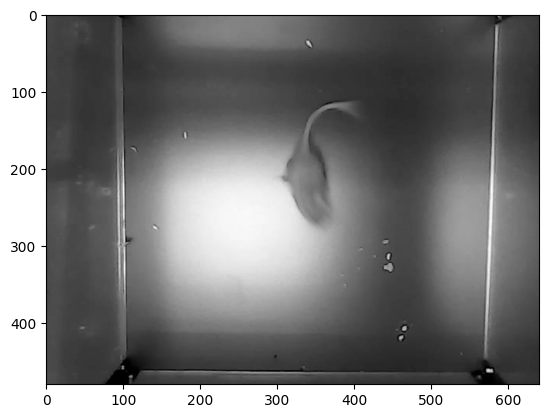

In [43]:

plt.imshow(imgs[2005], cmap='gray')

# Вычитание текущего кадра от фона.

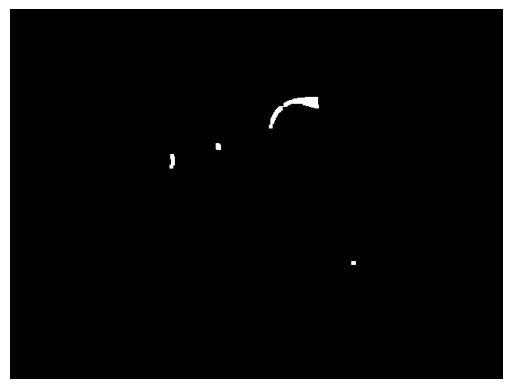

In [44]:
#cv2.addWeighted() - функция для взвешенного сложения двух изображений
diff_image=cv2.addWeighted(imgs[2005],1,new,-1,0)
# imgs[2005] * 1 + new * (-1) + 0  разность между текущим кадром и фоном 
#Там, где изображения одинаковы (фон), разность близка к 0
#Там, где есть движение (мышь), разность положительная
ret,thresh = cv2.threshold(diff_image, 20, 255,cv2.THRESH_BINARY)
#20 - пороговое значение (чувствительность) 255 - максимальное значение для пикселей выше порога
thresh=cv2.morphologyEx(thresh, cv2.MORPH_OPEN, np.ones((5,5),np.uint8), iterations=1)

#cv2.morphologyEx() - функция морфологических операций
#cv2.MORPH_OPEN - операция "открытие" (эрозия + дилатация)

thresh=cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, np.ones((5,5),np.uint8), iterations=1)

#cv2.MORPH_CLOSE - операция "закрытие" (дилатация + эрозия)
plt.imshow(thresh, cmap='gray')

plt.axis('off')  # Отключаем оси (по желанию)
# Сохраняем
plt.savefig('binary.png', dpi=300, bbox_inches='tight')
plt.show()

# Нахождение центра масс мышки

In [45]:
#функция нахождения моментов
mu=cv2.moments(thresh)
mc = (mu['m10'] / (mu['m00'] + 1e-5), mu['m01'] / (mu['m00'] + 1e-5))
#Моменты m00 - площадь объекта (сумма всех белых пикселей) m10 - сумма координат X всех белых пикселей m01 - сумма координат Y всех белых пикселей

mc

(345.8019680030002, 145.90282902125256)

# Отрисовка точки

In [46]:
image_test=cv2.copyTo(imgs[2005],imgs[2005])
#cv2.copyTo() - функция для копирования изображения с маской
cv2.circle(image_test,(int(mc[0]), int(mc[1])), 5, (0,0,255), -1)
#cv2.circle() - функция для рисования круга
#5 - радиус круга в пикселях
#-1 - толщина линии (отрицательное значение = закрашенный круг)

array([[67, 67, 68, ..., 56, 56, 56],
       [68, 68, 68, ..., 56, 56, 56],
       [70, 70, 69, ..., 56, 56, 56],
       ...,
       [77, 77, 77, ..., 49, 49, 49],
       [77, 77, 77, ..., 49, 49, 49],
       [77, 77, 77, ..., 49, 49, 49]], shape=(480, 640), dtype=uint8)

 # Модель фона и отслеживание движение мыши, кадр за кадром

In [4]:
def mod_fon (arr_image):
#Создает начальную модель фона - массив нулей такого же размера, как изображения (480×640)
  mod_fon = np.zeros(arr_image[1].shape, dtype='uint8')
#Создает список mom длиной равной количеству кадров, заполненный None. Здесь будут храниться координаты центра масс для каждого кадра
  mom=[None]*len(arr_image)
#Цикл по всем кадрам, кроме последних 10. Переменная k - номер текущего кадра.
  for k in range(len(arr_image)-10):
      
 #Экспоненциальное скользящее среднее:arr_image[k] * 0.5 + mod_fon * 0.5 + 0
#обновляет модель фона: 50% от текущего кадра + 50% от предыдущей модели фона
#Постепенно адаптирует фон к изменениям освещения(Экспоненциальное скользящее среднее)
    mod_fon=cv2.addWeighted(arr_image[k],0.5,mod_fon,0.5,0)
#arr_image[k] * 1 + mod_fon * (-1) + 0 Текущий кадр минус модель фона Выделяет движущиеся объекты (мышь)
    diff_image=cv2.addWeighted(arr_image[k],1,mod_fon,-1,0)
#Пороговая обработка
    ret,thresh = cv2.threshold(diff_image, 20, 255,cv2.THRESH_BINARY)
#Вычисляет моменты бинарного изображения для нахождения центра масс
    mu=cv2.moments(thresh)
#находим средние X Y координаты всех пискелей
      
    mom[k]=(mu['m10'] / (mu['m00'] + 1e-5), mu['m01'] / (mu['m00'] + 1e-5))
#m00 — это общая масса (сумма всех белых пикселей)
#m10 — это сумма X-координат всех белых пикселей, умноженных на их яркость
#m01 — это сумма Y-координат всех белых пикселей
      
#Если в текущем кадре мышь не найдена (центр в (0,0)), используем координаты из предыдущего кадра
    if(mom[k][0]==0 and mom[k][1]==0):
      mom[k]=mom[k-1]
#Если мышь "прыгнула" больше чем на 30 пикселей (слишком быстрое движение), считаем это ошибкой и оставляем предыдущие координаты
    if(k!=0):
      if((mom[k][0]-mom[k-1][0])>30 or (mom[k][1]-mom[k-1][1])>30):
        mom[k]=mom[k-1]
  return mom

In [48]:
data=mod_fon(imgs)
#data[10][1] показывает координату Y мыши на 11-м кадре видео
data[10][1]

212.99999164705915

In [79]:
data

[(318.921063294083, 260.7316723235965),
 (312.8795496549659, 269.40104613364707),
 (267.29684584330096, 277.6078071386599),
 (267.29684584330096, 277.6078071386599),
 (220.83333188997824, 208.66666530283226),
 (220.83333188997824, 208.66666530283226),
 (220.83333188997824, 208.66666530283226),
 (220.83333188997824, 208.66666530283226),
 (186.99999633333343, 194.4999961862746),
 (186.99999633333343, 194.4999961862746),
 (100.99999603921584, 212.99999164705915),
 (100.99999603921584, 212.99999164705915),
 (100.99999603921584, 212.99999164705915),
 (100.99999603921584, 212.99999164705915),
 (100.99999603921584, 212.99999164705915),
 (100.99999603921584, 212.99999164705915),
 (100.99999603921584, 212.99999164705915),
 (100.99999603921584, 212.99999164705915),
 (100.99999603921584, 212.99999164705915),
 (100.99999603921584, 212.99999164705915),
 (100.99999603921584, 212.99999164705915),
 (100.99999603921584, 212.99999164705915),
 (100.99999603921584, 212.99999164705915),
 (100.9999960392158

In [24]:
imgs[0]

array([[33, 33, 33, ..., 28, 28, 28],
       [33, 33, 33, ..., 27, 27, 27],
       [33, 33, 33, ..., 27, 27, 27],
       ...,
       [42, 42, 42, ..., 19, 19, 19],
       [42, 42, 42, ..., 19, 19, 19],
       [42, 42, 42, ..., 19, 19, 19]], shape=(480, 640), dtype=uint8)

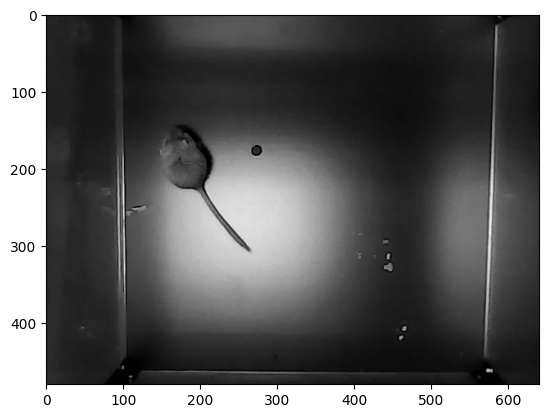

In [49]:
plt.imshow(imgs[0], cmap='gray')

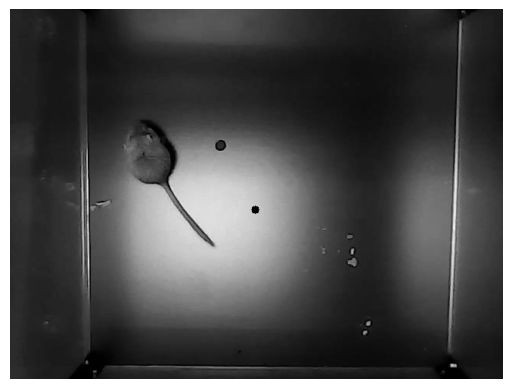

In [56]:

%matplotlib inline  

k = 0  # номер кадра
image_test = imgs[k].copy()
cv2.circle(image_test, (int(data[k][0]), int(data[k][1])), 5, (0,0,255), -1)

# Для СЕРОГО изображения:
plt.imshow(image_test, cmap='gray')
plt.axis('off')  # убирает оси
plt.show()

In [30]:
#число равно количеству кадров, для которых были вычислены координаты центра масс
len(data)

6075

In [31]:
# Здесь будут храниться X-координаты центра масс для каждого кадра.
D1=[None]*len(data)
#Здесь будут храниться Y-координаты центра масс для каждого кадра.
D2=[None]*len(data)
for k in range(len(data)-10):
  print(k)
  D1[k] = data[k][0]
  D2[k] = data[k][1]

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

# Построение траектории движения мыши на плоскости

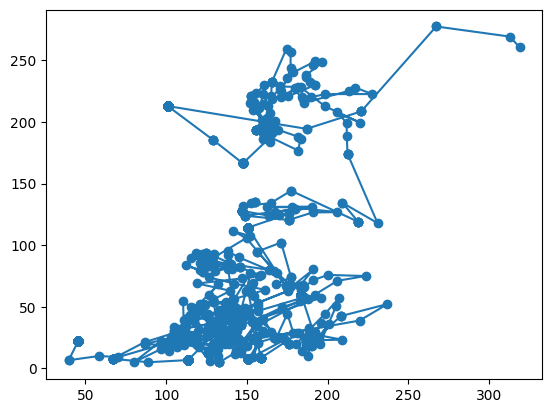

In [32]:

plt.plot(D1, D2, marker='o')